# Day 03 — What is Machine Learning?

> **Goal:** Build intuition for what ML does before diving into neural networks.

## The Big Idea

Traditional programming: **you write rules** → computer follows them.  
Machine learning: **you give data** → computer *learns* the rules.

```
Traditional:  Rules + Data  →  Answers
ML:           Data + Answers →  Rules (model)
```

We'll cover:
1. Supervised vs. unsupervised learning
2. Features, labels, and datasets
3. Train/test split — why it matters
4. Fitting a model (linear regression)
5. Loss functions — measuring "how wrong"
6. From ML to Deep Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 1. Supervised Learning

The most common type of ML. You have:
- **Features (X):** The input data (what you know)
- **Labels (y):** The answers (what you want to predict)

The model learns a mapping: **X → y**

### Example from your world (optics):
- **Features:** Lens curvature, glass type, aperture diameter
- **Label:** Resulting MTF (modulation transfer function) score
- **Task:** Predict MTF from lens parameters

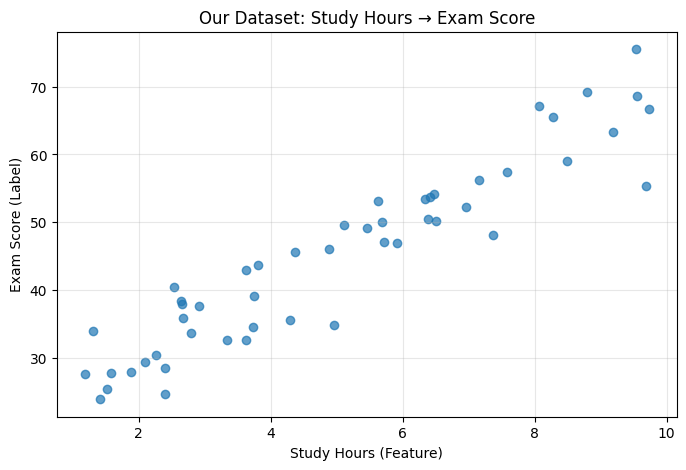

We have 50 data points
Feature (X) range: 1.2 - 9.7
Label (y) range: 23.9 - 75.5


In [2]:
# Let's create a simple dataset
# Imagine: X = study hours, y = exam score
np.random.seed(42)

X = np.random.uniform(1, 10, size=50)  # 50 students, 1-10 study hours
y = 5 * X + 20 + np.random.randn(50) * 5  # Score ≈ 5 * hours + 20 + noise

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7)
plt.xlabel("Study Hours (Feature)")
plt.ylabel("Exam Score (Label)")
plt.title("Our Dataset: Study Hours → Exam Score")
plt.grid(True, alpha=0.3)
plt.show()

print(f"We have {len(X)} data points")
print(f"Feature (X) range: {X.min():.1f} - {X.max():.1f}")
print(f"Label (y) range: {y.min():.1f} - {y.max():.1f}")

## 2. Train/Test Split

**Critical concept:** You can't test a model on the same data you trained it on!

That would be like giving a student the exam answers while studying, then testing them on the same questions — you'd learn nothing about their *actual* understanding.

Instead, we split the data:
- **Training set (80%):** The model learns from this
- **Test set (20%):** We evaluate the model on data it has *never seen*

Training set: 40 samples
Test set:     10 samples


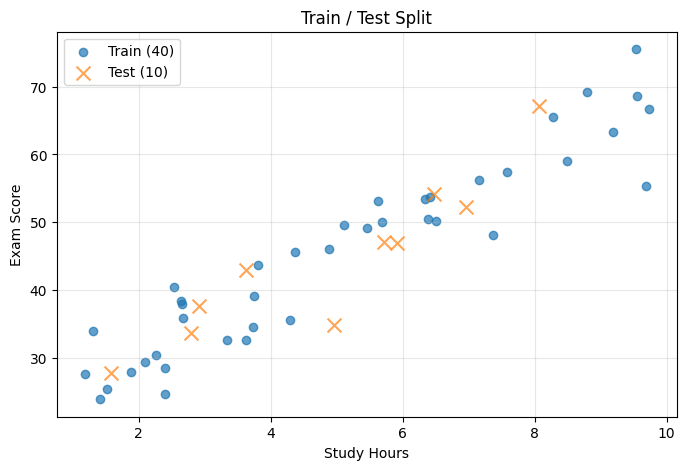

In [3]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")

# Visualize the split
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.7, label=f"Train ({len(X_train)})")
plt.scatter(X_test, y_test, alpha=0.7, marker="x", s=100, label=f"Test ({len(X_test)})")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Train / Test Split")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Fitting a Model (Linear Regression)

Linear regression finds the best line `y = w * x + b` that fits the data.

- **w** (weight/slope): how much y changes per unit of x
- **b** (bias/intercept): the baseline value when x = 0

"Best" means the line that minimizes the **loss** (error).

In [4]:
# sklearn expects 2D input: (n_samples, n_features)
X_train_2d = X_train.reshape(-1, 1)
X_test_2d = X_test.reshape(-1, 1)

print('X_train:', X_train)
print('X_train_2d:', X_train_2d)
print('Shapes:', X_train.shape, '->', X_train_2d.shape)

# Create and train the model
model = LinearRegression()
model.fit(X_train_2d, y_train)  # This is where learning happens!

# What did the model learn?
w = model.coef_[0]        # Weight (slope)
b = model.intercept_      # Bias (intercept)
print(f"Learned: y = {w:.2f} * x + {b:.2f}")
print(f"Ground truth was approximately: y = 5.00 * x + 20.00")

X_train: [8.49198377 2.40416776 1.87904903 6.41003511 6.38792636 1.52275251
 5.45659219 3.80539968 5.68061219 2.65064059 7.3726532  3.73818019
 5.10462986 9.6906883  2.53471711 4.37086107 3.32901983 5.62810995
 9.53996984 2.40395068 1.41805371 9.72918867 3.74152392 9.55642876
 2.25544475 7.58794548 9.18388362 8.27557613 4.29725659 2.09834411
 1.18526045 3.62930184 4.88750517 2.6636901  6.50667605 8.79558531
 1.30949669 2.6364247  6.33173112 7.15809724]
X_train_2d: [[8.49198377]
 [2.40416776]
 [1.87904903]
 [6.41003511]
 [6.38792636]
 [1.52275251]
 [5.45659219]
 [3.80539968]
 [5.68061219]
 [2.65064059]
 [7.3726532 ]
 [3.73818019]
 [5.10462986]
 [9.6906883 ]
 [2.53471711]
 [4.37086107]
 [3.32901983]
 [5.62810995]
 [9.53996984]
 [2.40395068]
 [1.41805371]
 [9.72918867]
 [3.74152392]
 [9.55642876]
 [2.25544475]
 [7.58794548]
 [9.18388362]
 [8.27557613]
 [4.29725659]
 [2.09834411]
 [1.18526045]
 [3.62930184]
 [4.88750517]
 [2.6636901 ]
 [6.50667605]
 [8.79558531]
 [1.30949669]
 [2.6364247 ]

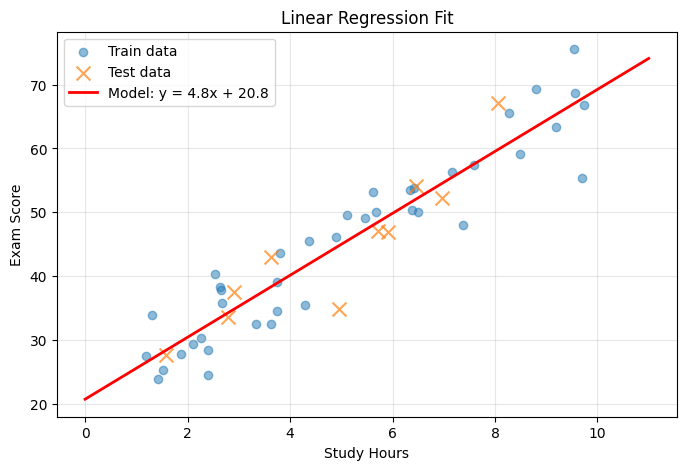

In [ ]:
# Visualize the fitted linecommand:_copilot.workspaceIndex.signInAgain?%5Bnull%5D
x_line = np.linspace(0, 11, 100)
y_line = w * x_line + b

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, alpha=0.5, label="Train data")
plt.scatter(X_test, y_test, alpha=0.7, marker="x", s=100, label="Test data")
plt.plot(x_line, y_line, "r-", linewidth=2, label=f"Model: y = {w:.1f}x + {b:.1f}")
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Linear Regression Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Loss Functions — Measuring "How Wrong"

The **loss** (or cost/error) tells us how far our predictions are from the true values.

### Mean Squared Error (MSE)

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

- $\hat{y}_i$ = prediction
- $y_i$ = true value
- Squaring makes all errors positive and penalizes big errors more
- Lower is better; 0 = perfect

In [5]:
# Make predictions
y_pred_train = model.predict(X_train_2d)
y_pred_test = model.predict(X_test_2d)

# Compute MSE
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"MSE on training data: {mse_train:.2f}")
print(f"MSE on test data:     {mse_test:.2f}")

# Let's compute MSE manually to understand it
errors = y_test - y_pred_test
mse_manual = np.mean(errors ** 2)
print(f"\nManual MSE check:     {mse_manual:.2f}  ✓")

MSE on training data: 20.75
MSE on test data:     19.91

Manual MSE check:     19.91  ✓


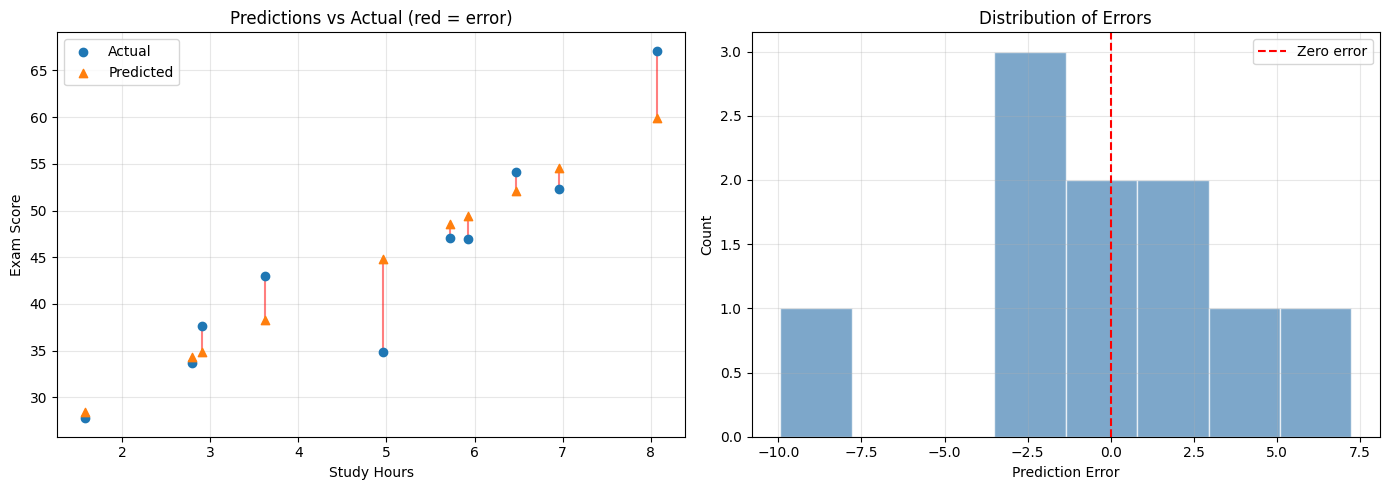

In [6]:
# Visualize the errors (residuals)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predictions vs actual with error lines
axes[0].scatter(X_test, y_test, label="Actual", zorder=5)
axes[0].scatter(X_test, y_pred_test, marker="^", label="Predicted", zorder=5)
for xi, yi, yp in zip(X_test, y_test, y_pred_test):
    axes[0].plot([xi, xi], [yi, yp], "r-", alpha=0.5)
axes[0].set_xlabel("Study Hours")
axes[0].set_ylabel("Exam Score")
axes[0].set_title("Predictions vs Actual (red = error)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: error histogram
axes[1].hist(errors, bins=8, alpha=0.7, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--", label="Zero error")
axes[1].set_xlabel("Prediction Error")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Errors")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Classification: A Different Kind of ML Task

So far we predicted a *number* (regression). But often we want to predict a *category*:
- Is this image a cat or a dog? → **Classification**
- Is this lens defective or good? → **Classification**
- What digit is in this image (0-9)? → **Classification**

X_cls shape: (200, 2), dtype: float64
y_cls shape: (200,), dtype: int64


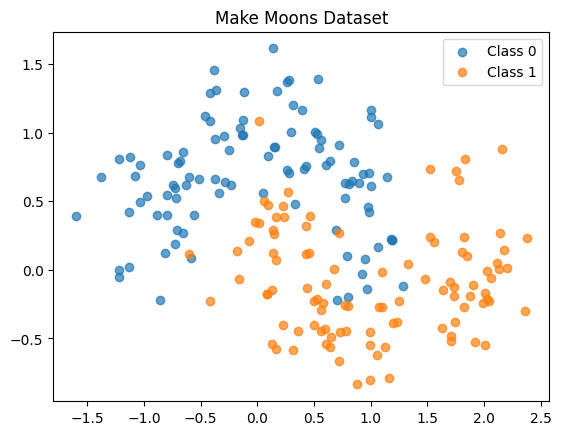

Classification accuracy: 85.0%


In [10]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Generate two-class "moon" dataset
X_cls, y_cls = make_moons(n_samples=200, noise=0.25, random_state=42)
print(f"X_cls shape: {X_cls.shape}, dtype: {X_cls.dtype}")
print(f"y_cls shape: {y_cls.shape}, dtype: {y_cls.dtype}")

plt.scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1], label="Class 0", alpha=0.7)
plt.scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1], label="Class 1", alpha=0.7)
plt.legend()
plt.title("Make Moons Dataset")
plt.show()

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Train a simple classifier
clf = LogisticRegression()
clf.fit(X_tr, y_tr)

# Evaluate
y_pred_cls = clf.predict(X_te)
acc = accuracy_score(y_te, y_pred_cls)
print(f"Classification accuracy: {acc:.1%}")

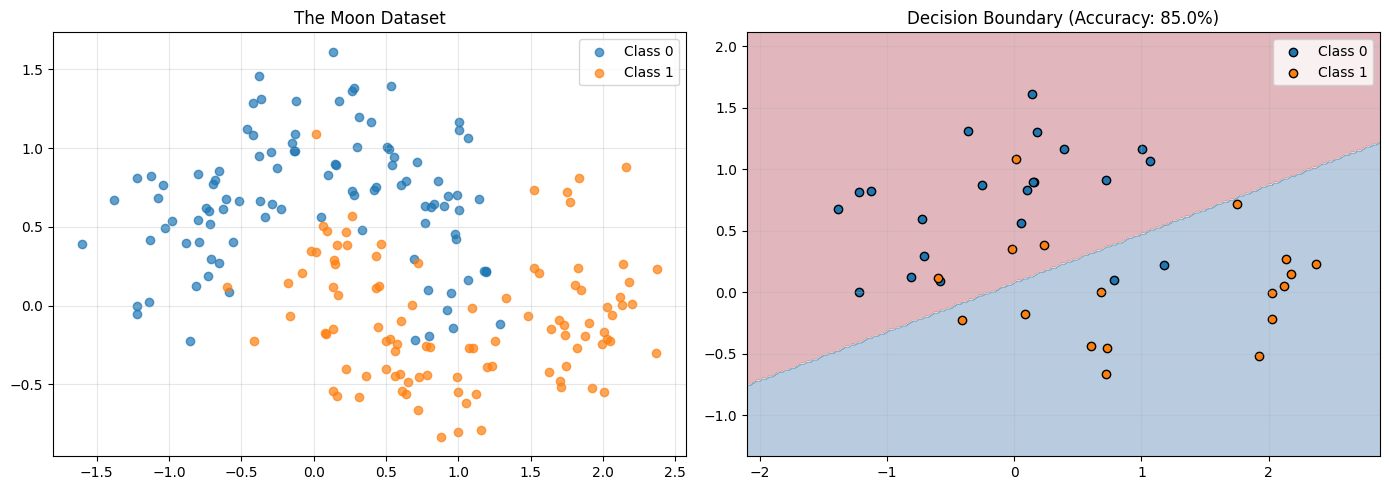

Notice: a straight line can't perfectly separate these moons!
This is why we need neural networks — they can learn curved boundaries.


In [11]:
# Visualize the decision boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: The data
for cls in [0, 1]:
    mask = y_cls == cls
    axes[0].scatter(X_cls[mask, 0], X_cls[mask, 1], label=f"Class {cls}", alpha=0.7)
axes[0].set_title("The Moon Dataset")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Decision boundary
xx, yy = np.meshgrid(np.linspace(X_cls[:, 0].min()-0.5, X_cls[:, 0].max()+0.5, 200),
                     np.linspace(X_cls[:, 1].min()-0.5, X_cls[:, 1].max()+0.5, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap="RdBu")
for cls in [0, 1]:
    mask = y_te == cls
    axes[1].scatter(X_te[mask, 0], X_te[mask, 1], label=f"Class {cls}", edgecolors="k")
axes[1].set_title(f"Decision Boundary (Accuracy: {acc:.1%})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice: a straight line can't perfectly separate these moons!")
print("This is why we need neural networks — they can learn curved boundaries.")

## 6. From ML to Deep Learning

What we just did (linear regression, logistic regression) is **basic ML**.

**Deep Learning** is ML with *neural networks* — models that can learn complex, non-linear patterns.

| Traditional ML | Deep Learning |
|---------------|---------------|
| You design features | Network learns features automatically |
| Works on small data | Needs more data, but more powerful |
| Linear boundaries | Complex, non-linear boundaries |
| Fast to train | Slower, needs GPU |
| Easy to interpret | Harder to interpret ("black box") |

### The Deep Learning Training Loop

Starting tomorrow, you'll learn PyTorch and implement this loop:

```
for epoch in range(num_epochs):
    prediction = model(data)         # 1. Forward pass
    loss = loss_function(prediction)  # 2. Compute loss
    loss.backward()                   # 3. Backward pass (compute gradients)
    optimizer.step()                  # 4. Update weights
    optimizer.zero_grad()             # 5. Clear gradients
```

This loop is the **heart** of all deep learning. Everything else is details.

---

## ✏️ Exercises

In [ ]:
# Exercise 1: Compute MSE by hand (without sklearn) for these predictions:
y_true = np.array([3.0, -0.5, 2.0, 7.0])
y_pred = np.array([2.5, 0.0, 2.1, 7.8])

# Calculate: MSE = mean of (y_pred - y_true)^2
# Your code here:

In [ ]:
# Exercise 2: Try changing the noise level in our linear regression dataset.
# Create data with noise=20 instead of noise=5. 
# Fit a model and compare the MSE. What happens with more noise?

# Your code here:

---

## 📝 Key Takeaways

1. **ML learns rules from data** instead of you writing them.
2. **Supervised learning** = features (X) + labels (y) → model learns X → y.
3. **Train/test split** is essential — never evaluate on training data.
4. **Loss function** measures how wrong the model is. Training = minimizing loss.
5. **Classification** predicts categories; **regression** predicts numbers.
6. **Linear models** can only draw straight boundaries. Neural networks can learn curves.
7. The DL training loop: **forward → loss → backward → step → zero_grad**.

**Tomorrow:** We start PyTorch! First up: tensors — the fundamental data structure.